# ETS MARL — Multi-Agent RL for EU Emissions Trading

**Technology-Specific Energy Mix | Real CapEx | Construction Queues | PPO**

This notebook is a testing playground for the ETS MARL simulation.
It clones the repository, installs dependencies, runs tests, trains agents,
and visualizes results — all within Google Colab.

---

### Model Overview
- **4 agents** representing European electricity utilities (10 TWh/year each)
- **5 technologies**: Coal, Gas CCGT, Onshore Wind, Offshore Wind, Solar PV
- **Real-data-grounded** CapEx (IRENA 2024), emission factors (IPCC AR5), deployment delays
- **EU ETS mechanics**: uniform-price auction, MSR, LRF (Fit for 55), 100% auctioning
- **PPO agents** with two-phase decisions (auction + secondary market)
- **Greening-only** constraint: agents can only add renewables, fossil can only decrease

## 1. Setup — Clone Repository & Install Dependencies

In [1]:
# Clone the repository (update URL to your repo)
!git clone https://github.com/DJH961/Thesis-Energy-Auction.git 2>/dev/null || echo 'Repo already cloned'

import os
os.chdir('Thesis-Energy-Auction/ets_marl ppo')
print(f'Working directory: {os.getcwd()}')

Working directory: /content/Thesis-Energy-Auction/ets_marl ppo


In [2]:
# Install dependencies
!pip install -q gymnasium numpy torch pyyaml pandas matplotlib seaborn pytest numpy-groupies

# Verify GPU availability
import torch
print(f'PyTorch version: {torch.__version__}')
print(f'CUDA available: {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.8/40.8 kB 4.1 MB/s eta 0:00:00
PyTorch version: 2.10.0+cu128
CUDA available: True
GPU: Tesla T4


## 2. Run Tests — Verify Everything Works

In [3]:
!python -m pytest tests/ -v

============================= test session starts ==============================
platform linux -- Python 3.12.12, pytest-8.4.2, pluggy-1.6.0 -- /usr/bin/python3
cachedir: .pytest_cache
rootdir: /content/Thesis-Energy-Auction/ets_marl ppo
configfile: pyproject.toml
plugins: typeguard-4.5.1, anyio-4.12.1, langsmith-0.7.7
collected 33 items                                                             

tests/test_cap_schedule.py::test_cap_year_0 PASSED                       [  3%]
tests/test_cap_schedule.py::test_cap_year_1_lrf_phase1 PASSED            [  6%]
tests/test_cap_schedule.py::test_cap_year_5_switches_to_phase2 PASSED    [  9%]
tests/test_cap_schedule.py::test_cap_strictly_decreasing PASSED          [ 12%]
tests/test_cap_schedule.py::test_cap_year_10 PASSED                      [ 15%]
tests/test_cap_schedule.py::test_msr_no_adjustment_within_band PASSED    [ 18%]
tests/test_cap_schedule.py::test_msr_withhold_when_tnac_high PASSED      [ 21%]
tests/test_cap_schedule.py::test_msr_

## 3. Explore the Environment

In [4]:
import sys
sys.path.insert(0, '.')

import yaml
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.environment.ets_environment import ETSEnvironment
from src.environment.company import TECH_NAMES

with open('configs/default.yaml') as f:
    config = yaml.safe_load(f)

env = ETSEnvironment(config, seed=42)
obs1, _ = env.reset()

print('=== Environment Summary ===')
print(f'Agents: {env.n_agents}')
print(f'Years: {env.n_years}')
print(f'Technologies: {TECH_NAMES}')
print(f'Phase 1 obs dim: {obs1.shape[1]}')
print(f'Initial cap: {env.cap_schedule.get_cap(0):.2f} Mt')
print()

tech_names = config['technologies']['names']
for i, c in enumerate(env.companies):
    mix_str = ' | '.join([f'{tech_names[t]}: {c.mix[t]*100:.0f}%' for t in range(5)])
    print(f'A{i+1}: {mix_str}')
    print(f'     Emissions: {c.compute_emissions():.2f} Mt | '
          f'Green: {c.green_frac*100:.0f}% | '
          f'Op. Cost: {c.compute_operational_cost():.0f} M€/yr | '
          f'Avg EF: {c.weighted_emission_factor:.3f} tCO2/MWh')

=== Environment Summary ===
Agents: 4
Years: 12
Technologies: ['coal', 'gas', 'onshore_wind', 'offshore_wind', 'solar']
Phase 1 obs dim: 24
Initial cap: 9.10 Mt

A1: coal: 40% | gas: 40% | onshore_wind: 10% | offshore_wind: 5% | solar: 5%
     Emissions: 5.28 Mt | Green: 20% | Op. Cost: 554 M€/yr | Avg EF: 0.528 tCO2/MWh
A2: coal: 15% | gas: 45% | onshore_wind: 20% | offshore_wind: 10% | solar: 10%
     Emissions: 3.52 Mt | Green: 40% | Op. Cost: 446 M€/yr | Avg EF: 0.352 tCO2/MWh
A3: coal: 5% | gas: 25% | onshore_wind: 35% | offshore_wind: 20% | solar: 15%
     Emissions: 1.77 Mt | Green: 70% | Op. Cost: 342 M€/yr | Avg EF: 0.177 tCO2/MWh
A4: coal: 0% | gas: 10% | onshore_wind: 30% | offshore_wind: 35% | solar: 25%
     Emissions: 0.69 Mt | Green: 90% | Op. Cost: 296 M€/yr | Avg EF: 0.069 tCO2/MWh


## 4. Run a Random-Policy Episode (Baseline)

In [5]:
env = ETSEnvironment(config, seed=42)
obs1, _ = env.reset(seed=42)
n_agents = env.n_agents
rng = np.random.default_rng(42)

year_data = []

for year in range(config['simulation']['n_years']):
    # Random auction actions
    auction_actions = rng.uniform(
        [20.0, 0.0, 0.0, -1.0, -1.0, -1.0],
        [200.0, 5.0, 0.05, 1.0, 1.0, 1.0],
        size=(n_agents, 6)
    ).astype(np.float32)

    obs2, _ = env.step_auction(auction_actions)

    # Random secondary actions
    secondary_actions = rng.uniform(
        [0.5, -5.0], [2.0, 5.0], size=(n_agents, 2)
    ).astype(np.float32)

    obs1, rewards, terminated, _, info = env.step_secondary(secondary_actions)
    log = info['year_log']

    row = {'year': year, 'cap': log['cap'], 'price': log['clearing_price']}
    for i in range(n_agents):
        row[f'green_A{i+1}'] = log['green_fracs'][i]
        row[f'emissions_A{i+1}'] = log['emissions'][i]
        row[f'reward_A{i+1}'] = rewards[i]
    year_data.append(row)

    if terminated:
        break

df = pd.DataFrame(year_data)
print(df[['year', 'cap', 'price']].to_string(index=False))

 year      cap      price
    0 9.100000 157.005142
    1 8.708700  60.843681
    2 8.334226  72.846878
    3 7.975854  51.819099
    4 7.624917  79.682419
    5 7.289420 169.362152
    6 6.968686  42.096428
    7 6.662064  71.560318
    8 6.368933  40.788212
    9 6.088700 171.843491
   10 5.820797 164.790527
   11 5.564682 138.415390


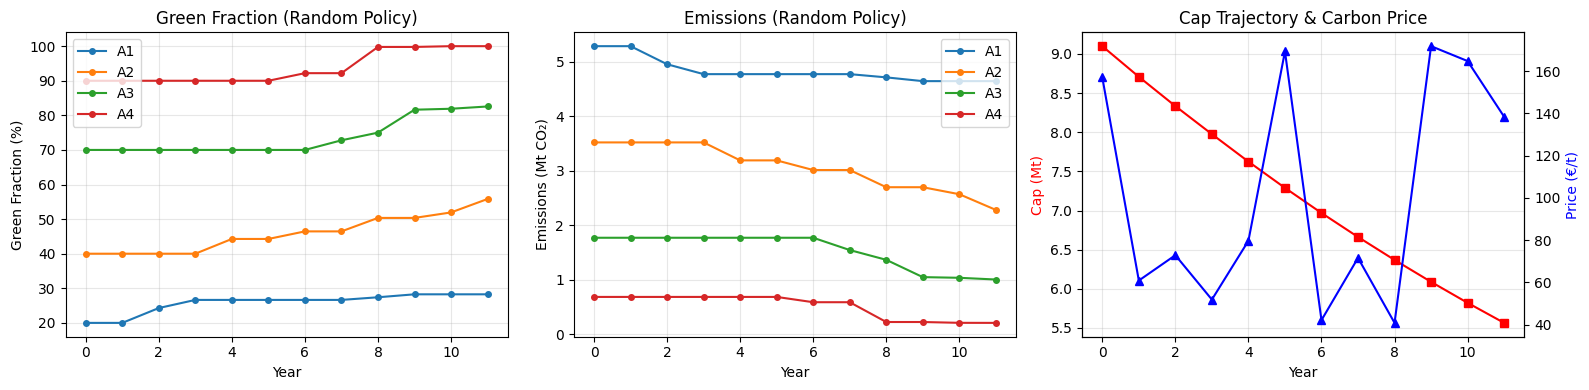

In [6]:
# Plot: Green fraction evolution (random policy)
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Green fracs
ax = axes[0]
for i in range(n_agents):
    ax.plot(df['year'], df[f'green_A{i+1}'] * 100, label=f'A{i+1}', marker='o', markersize=4)
ax.set_xlabel('Year')
ax.set_ylabel('Green Fraction (%)')
ax.set_title('Green Fraction (Random Policy)')
ax.legend()
ax.grid(True, alpha=0.3)

# Emissions
ax = axes[1]
for i in range(n_agents):
    ax.plot(df['year'], df[f'emissions_A{i+1}'], label=f'A{i+1}', marker='o', markersize=4)
ax.set_xlabel('Year')
ax.set_ylabel('Emissions (Mt CO₂)')
ax.set_title('Emissions (Random Policy)')
ax.legend()
ax.grid(True, alpha=0.3)

# Cap & Price
ax = axes[2]
ax.plot(df['year'], df['cap'], label='Cap (Mt)', marker='s', color='red')
ax2 = ax.twinx()
ax2.plot(df['year'], df['price'], label='Price (€/t)', marker='^', color='blue')
ax.set_xlabel('Year')
ax.set_ylabel('Cap (Mt)', color='red')
ax2.set_ylabel('Price (€/t)', color='blue')
ax.set_title('Cap Trajectory & Carbon Price')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 5. Train PPO Agents (Short Run)

In [7]:
from scripts.train import train_one_seed

# Override for quick Colab run (reduce episodes)
train_config = config.copy()
train_config['simulation'] = dict(config['simulation'])
train_config['simulation']['n_episodes'] = 500  # Increase for better results
train_config['logging'] = dict(config['logging'])
train_config['logging']['log_interval'] = 50
train_config['logging']['save_interval'] = 100

train_one_seed(train_config, seed=42)


Training — seed 42, 4 agents, PPO, two-phase
Technology-specific mix | Real CapEx | Construction queues
P1-P4 roadmap improvements active
────────────────────────────────────────────────────────────────────────────────────────────────────────────────
Ep     0 │ price= 150.1  cap=    6  TNAC=    17 │ sec_p=153.3  sec_vol=    6.0  match=75% │ ent=0.0500  shaping=1.000 [cyc=A1]
         BankSt   Alloc   Emiss  SecNet    Hold Short/yr    Pen/yr  Green  ΔGreen   Bid  │   EpRew  EpShort     EpPen   aLoss   cLoss
  A1*:     0.0     0.2     4.4    +0.0     0.0     4.17     417.5  31.4%   +1.3% 150.3  │  -18.52    42.37    4236.6 -0.0188 73.5259
  A2 :     0.0     1.1     3.4    -1.1     0.0     3.35     335.1  42.1%   +1.0% 103.1  │  -12.04    31.63    3135.4    n/a     n/a 
  A3 :     6.9     0.0     1.0    +0.0     5.9     0.00       0.0  83.2%   +0.0% 135.6  │   -4.98     1.16      55.2    n/a     n/a 
  A4 :     9.7     1.2     0.2    +1.1    11.7     0.00       0.0 100.0%   +0.0% 120.4  

## 6. Analyze Training Results

In [15]:
# Load training logs
ep_df = pd.read_csv('results/training_log_s42.csv')
yr_df = pd.read_csv('results/year_log_s42.csv')

print(f'Training episodes: {len(ep_df)}')
print(f'Year-level records: {len(yr_df)}')
ep_df.tail()

Training episodes: 5050
Year-level records: 60600


,episode,clearing_price_last,cap_last,entropy_coef,shaping_weight,entropy_decay_triggered,active_agent,reward_A1,green_frac_A1,delta_green_A1,...,delta_green_A4,penalty_A4,shortfall_A4,queue_size_A4,actor_loss_A4,critic_loss_A4,bid_price_A4,secondary_volume,secondary_avg_price,secondary_match_rate
5045,5045,196.785080,5.564682,0.05,0.0,0,1,-24.6052,0.2096,0.00956,...,0.00680,0.000000,0.000000,3.92,0.000000,0.000000,187.81,0.0,0.0,0.0
5046,5046,199.997345,5.564682,0.05,0.0,0,2,-25.0162,0.2041,0.00410,...,0.00391,0.000000,0.000000,3.75,0.000000,0.000000,199.56,0.0,0.0,0.0
5047,5047,199.992889,5.564682,0.05,0.0,0,3,-24.2902,0.2143,0.01427,...,0.00812,0.000000,0.000000,3.42,-0.001255,1.091664,195.73,0.0,0.0,0.0
5048,5048,199.971252,5.564682,0.05,0.0,0,0,-24.0095,0.2007,0.00072,...,0.00074,19.490361,0.239912,4.08,0.000000,0.000000,193.76,0.0,0.0,0.0
5049,5049,199.996460,5.564682,0.05,0.0,0,1,-21.4159,0.2009,0.00086,...,0.00980,0.000000,0.000000,3.08,0.000000,0.000000,199.65,0.0,0.0,0.0


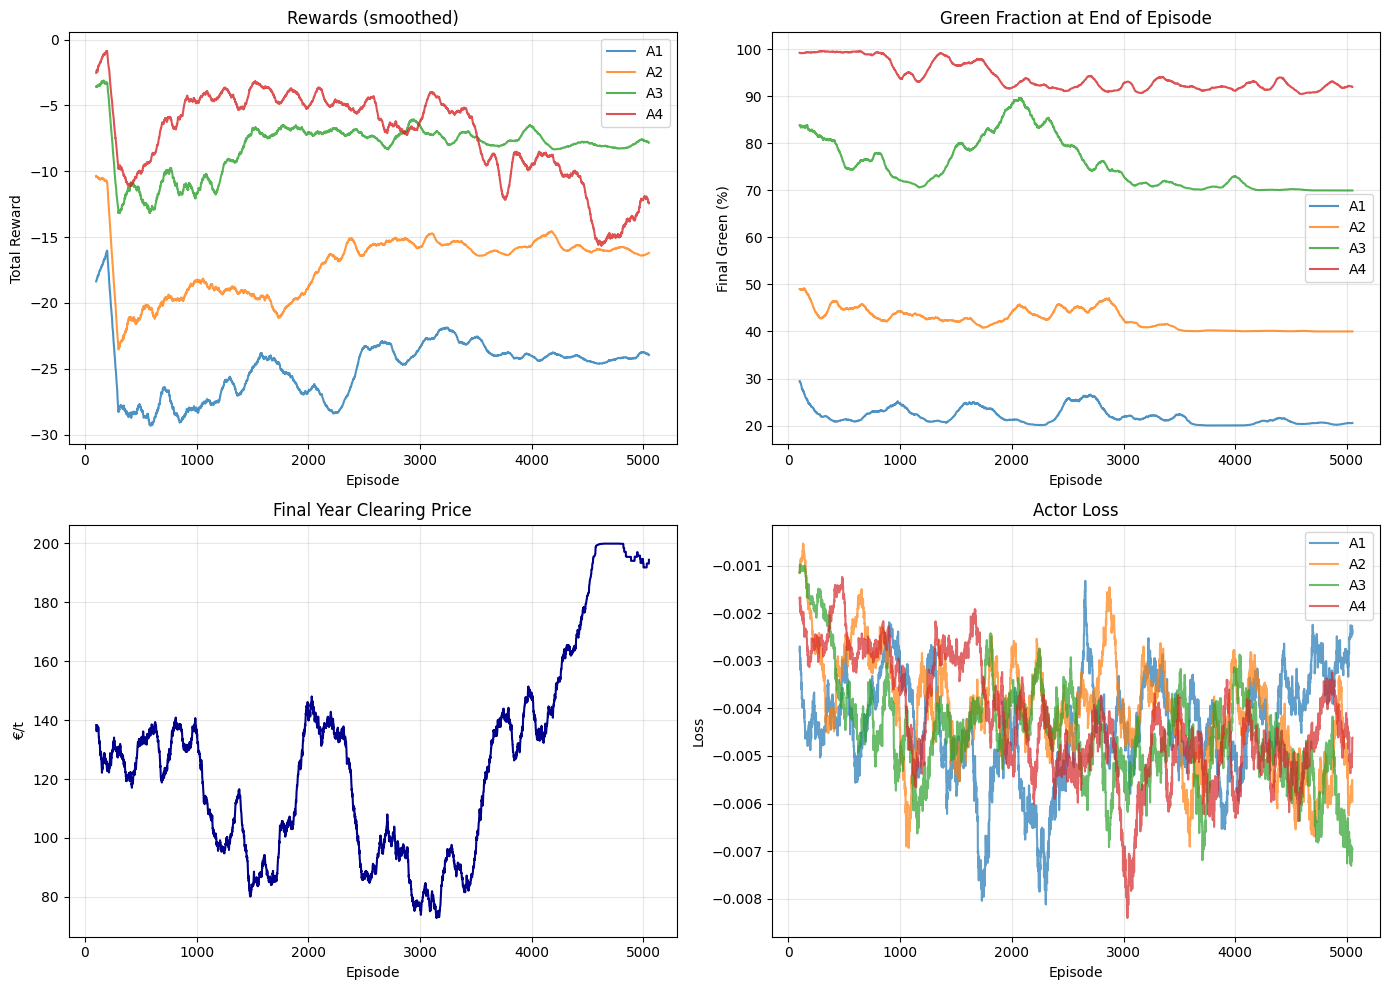

In [16]:
# Plot training curves
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
n_agents = config['companies']['n_agents']
window = max(1, len(ep_df) // 50)  # smoothing window

# 1. Rewards
ax = axes[0, 0]
for i in range(n_agents):
    col = f'reward_A{i+1}'
    ax.plot(ep_df['episode'], ep_df[col].rolling(window).mean(), label=f'A{i+1}', alpha=0.8)
ax.set_xlabel('Episode')
ax.set_ylabel('Total Reward')
ax.set_title('Rewards (smoothed)')
ax.legend()
ax.grid(True, alpha=0.3)

# 2. Green fractions
ax = axes[0, 1]
for i in range(n_agents):
    col = f'green_frac_A{i+1}'
    ax.plot(ep_df['episode'], ep_df[col].rolling(window).mean() * 100, label=f'A{i+1}', alpha=0.8)
ax.set_xlabel('Episode')
ax.set_ylabel('Final Green (%)')
ax.set_title('Green Fraction at End of Episode')
ax.legend()
ax.grid(True, alpha=0.3)

# 3. Clearing price
ax = axes[1, 0]
ax.plot(ep_df['episode'], ep_df['clearing_price_last'].rolling(window).mean(), color='darkblue')
ax.set_xlabel('Episode')
ax.set_ylabel('€/t')
ax.set_title('Final Year Clearing Price')
ax.grid(True, alpha=0.3)

# 4. Actor loss
ax = axes[1, 1]
for i in range(n_agents):
    col = f'actor_loss_A{i+1}'
    ax.plot(ep_df['episode'], ep_df[col].rolling(window).mean(), label=f'A{i+1}', alpha=0.7)
ax.set_xlabel('Episode')
ax.set_ylabel('Loss')
ax.set_title('Actor Loss')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

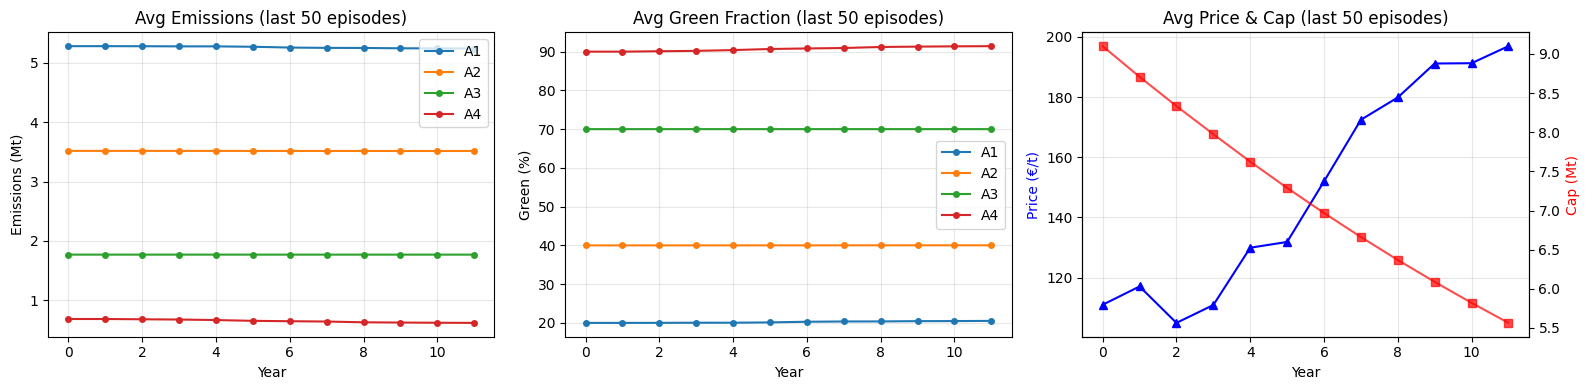

In [17]:
# Year-level analysis: last 50 episodes
last_eps = yr_df['episode'].unique()[-50:]
recent = yr_df[yr_df['episode'].isin(last_eps)]

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Emissions by year (averaged over recent episodes)
ax = axes[0]
for i in range(n_agents):
    avg = recent.groupby('year')[f'emissions_A{i+1}'].mean()
    ax.plot(avg.index, avg.values, label=f'A{i+1}', marker='o', markersize=4)
ax.set_xlabel('Year')
ax.set_ylabel('Emissions (Mt)')
ax.set_title('Avg Emissions (last 50 episodes)')
ax.legend()
ax.grid(True, alpha=0.3)

# Green frac by year
ax = axes[1]
for i in range(n_agents):
    avg = recent.groupby('year')[f'green_frac_A{i+1}'].mean()
    ax.plot(avg.index, avg.values * 100, label=f'A{i+1}', marker='o', markersize=4)
ax.set_xlabel('Year')
ax.set_ylabel('Green (%)')
ax.set_title('Avg Green Fraction (last 50 episodes)')
ax.legend()
ax.grid(True, alpha=0.3)

# Carbon price trajectory
ax = axes[2]
avg_price = recent.groupby('year')['clearing_price'].mean()
avg_cap = recent.groupby('year')['cap'].mean()
ax.plot(avg_price.index, avg_price.values, label='Clearing Price', marker='^', color='blue')
ax2 = ax.twinx()
ax2.plot(avg_cap.index, avg_cap.values, label='Cap', marker='s', color='red', alpha=0.7)
ax.set_xlabel('Year')
ax.set_ylabel('Price (€/t)', color='blue')
ax2.set_ylabel('Cap (Mt)', color='red')
ax.set_title('Avg Price & Cap (last 50 episodes)')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 7. Evaluate Best Agents (Deterministic)

In [11]:
from scripts.train import build_agents

# Load best checkpoints
eval_env = ETSEnvironment(config, seed=0)
eval_agents = build_agents(eval_env, config, seed=0)

ckpt_dir = 'results/checkpoints_s42'
for i, agent in enumerate(eval_agents):
    ckpt_path = os.path.join(ckpt_dir, f'agent_{i}_best.pt')
    if os.path.exists(ckpt_path):
        agent.load(ckpt_path)
        print(f'Loaded agent {i}')
    else:
        print(f'No checkpoint for agent {i} — using untrained policy')

# Run deterministic evaluation
obs1, _ = eval_env.reset(seed=0)
eval_data = []

for year in range(config['simulation']['n_years']):
    auction_actions = np.zeros((n_agents, 6), dtype=np.float32)
    for i in range(n_agents):
        action, _, _ = eval_agents[i].select_auction_action(obs1[i], deterministic=True)
        auction_actions[i] = action
    obs2, _ = eval_env.step_auction(auction_actions)

    secondary_actions = np.zeros((n_agents, 2), dtype=np.float32)
    for i in range(n_agents):
        action, _, _ = eval_agents[i].select_secondary_action(obs2[i], deterministic=True)
        secondary_actions[i] = action

    obs1, rewards, terminated, _, info = eval_env.step_secondary(secondary_actions)
    log = info['year_log']

    row = {'year': year, 'cap': log['cap'], 'price': log['clearing_price']}
    for i in range(n_agents):
        row[f'green_A{i+1}'] = log['green_fracs'][i]
        row[f'emissions_A{i+1}'] = log['emissions'][i]
        for t in range(5):
            row[f'mix_A{i+1}_{tech_names[t]}'] = log['tech_mixes'][i][t]
    eval_data.append(row)
    if terminated:
        break

eval_df = pd.DataFrame(eval_data)
print(eval_df[['year', 'cap', 'price'] + [f'green_A{i+1}' for i in range(n_agents)]].to_string(index=False))

Loaded agent 0
Loaded agent 1
Loaded agent 2
Loaded agent 3
 year      cap      price  green_A1  green_A2  green_A3  green_A4
    0 9.100000  92.307259  0.200000  0.400000  0.700000  0.900000
    1 8.708700  91.948357  0.200000  0.400000  0.700000  0.900000
    2 8.334226  91.477409  0.200000  0.400000  0.700000  0.900000
    3 7.975854 113.553650  0.200000  0.406654  0.700000  0.909526
    4 7.624917 113.292282  0.200000  0.406654  0.700000  0.909526
    5 7.289420 113.427399  0.210016  0.413181  0.700000  0.918792
    6 6.968686 113.152428  0.220135  0.413181  0.704941  0.926901
    7 6.662064 113.268707  0.230768  0.418998  0.709639  0.934567
    8 6.368933 113.032028  0.230768  0.418998  0.714243  0.941731
    9 6.088700 113.165833  0.230768  0.424655  0.718216  0.948338
   10 5.820797 113.129639  0.230768  0.424655  0.721872  0.954212
   11 5.564682 113.083603  0.240870  0.424655  0.721872  0.959762


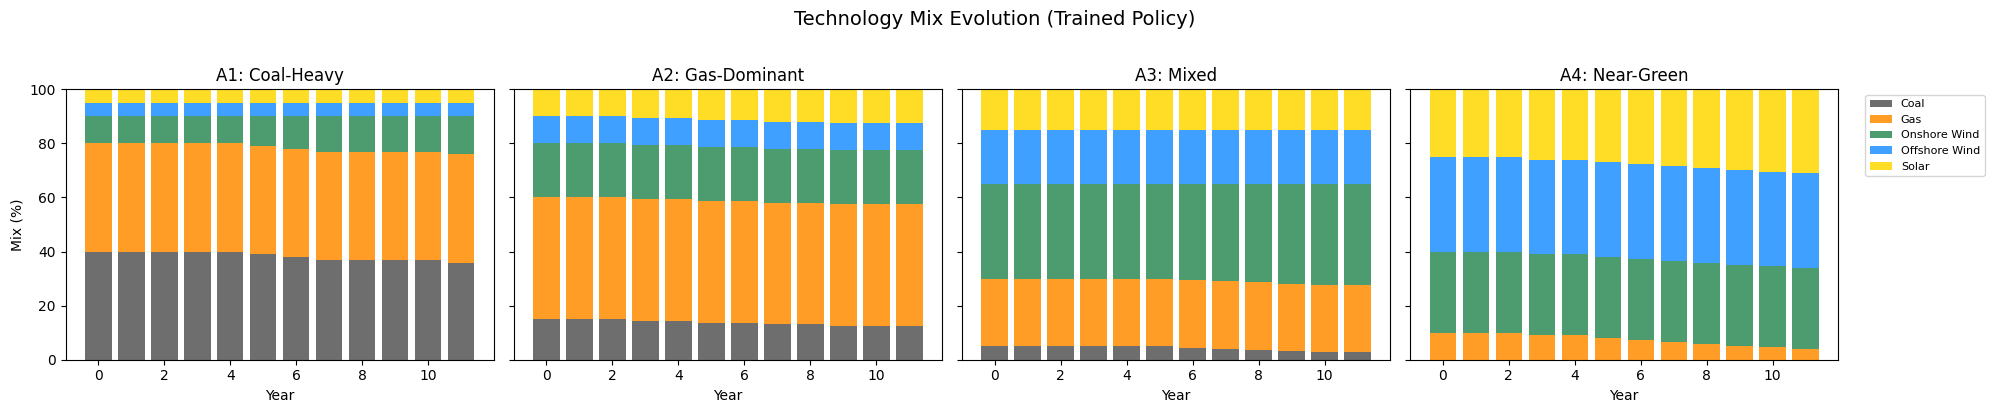

In [12]:
# Technology mix evolution per agent
tech_names = config['technologies']['names']
colors = {'coal': '#555555', 'gas': '#FF8C00', 'onshore_wind': '#2E8B57',
          'offshore_wind': '#1E90FF', 'solar': '#FFD700'}

fig, axes = plt.subplots(1, n_agents, figsize=(5*n_agents, 4), sharey=True)
archetypes = ['Coal-Heavy', 'Gas-Dominant', 'Mixed', 'Near-Green']

for i in range(n_agents):
    ax = axes[i] if n_agents > 1 else axes
    bottom = np.zeros(len(eval_df))
    for t in range(5):
        vals = eval_df[f'mix_A{i+1}_{tech_names[t]}'].values * 100
        ax.bar(eval_df['year'], vals, bottom=bottom,
               label=tech_names[t].replace('_', ' ').title(),
               color=colors[tech_names[t]], alpha=0.85)
        bottom += vals
    ax.set_xlabel('Year')
    if i == 0:
        ax.set_ylabel('Mix (%)')
    ax.set_title(f'A{i+1}: {archetypes[i]}')
    ax.set_ylim(0, 100)
    if i == n_agents - 1:
        ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)

plt.suptitle('Technology Mix Evolution (Trained Policy)', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 8. Investment Cost Sanity Check

Verify that investment costs match real-world data (action plan §2).

In [20]:
env = ETSEnvironment(config, seed=42)
env.reset()
c = env.companies[0]  # A1: coal-heavy

print('=== Investment Cost Sanity Check ===')
print(f'Company output: {c.output_twh} TWh/year = {c.output_mwh/1e6:.0f} million MWh')
print()

for tech_idx, name in [(2, 'Onshore Wind'), (3, 'Offshore Wind'), (4, 'Solar PV')]:
    frac = 0.03  # 3% of output
    delta_mwh = frac * c.output_mwh
    cf = c.capacity_factors[tech_idx]
    delta_mw = delta_mwh / (cf * 8760)
    cost = c.compute_investment_cost(tech_idx, frac)
    print(f'{name}:')
    print(f'  Shift: {frac*100:.0f}% = {delta_mwh/1e6:.0f} GWh/yr')
    print(f'  New capacity: {delta_mw:.0f} MW (at CF={cf:.0%})')
    print(f'  CapEx: {c.capex[tech_idx]:.0f} €/kW')
    print(f'  Investment cost: {cost:.1f} M€')
    print()

=== Investment Cost Sanity Check ===
Company output: 10.0 TWh/year = 10 million MWh

Onshore Wind:
  Shift: 3% = 0 GWh/yr
  New capacity: 98 MW (at CF=35%)
  CapEx: 1350 €/kW
  Investment cost: 132.7 M€

Offshore Wind:
  Shift: 3% = 0 GWh/yr
  New capacity: 73 MW (at CF=47%)
  CapEx: 3250 €/kW
  Investment cost: 237.7 M€

Solar PV:
  Shift: 3% = 0 GWh/yr
  New capacity: 201 MW (at CF=17%)
  CapEx: 750 €/kW
  Investment cost: 152.6 M€



## 9. Full Training Run (Longer)

Uncomment and run for a more complete training. Takes ~15-30 min on Colab GPU.

In [ ]:
# # Full training (uncomment to run)
full_config = config.copy()
full_config['simulation'] = dict(config['simulation'])
full_config['simulation']['n_episodes'] = 10100
full_config['logging'] = dict(config['logging'])
full_config['logging']['log_interval'] = 101
full_config['logging']['results_dir'] = 'results/'

train_one_seed(full_config, seed=42)


Training — seed 42, 4 agents, PPO, two-phase
Technology-specific mix | Real CapEx | Construction queues
P1-P4 roadmap improvements active
────────────────────────────────────────────────────────────────────────────────────────────────────────────────
Ep     0 │ price= 144.9  cap=    6  TNAC=    16 │ sec_p=210.4  sec_vol=   18.6  match=75% │ ent=0.0500  shaping=1.000 [cyc=A1]
         BankSt   Alloc   Emiss  SecNet    Hold Short/yr    Pen/yr  Green  ΔGreen   Bid  │   EpRew  EpShort     EpPen   aLoss   cLoss
  A1*:     0.0     1.1     4.1    -1.1     0.0     4.12     412.2  34.7%   +2.0% 115.5  │  -19.28    45.40    4539.8 -0.0103 75.8320
  A2 :     0.0     1.3     2.5    +0.0     0.0     1.21     121.4  53.3%   +0.0% 107.2  │   -7.33    16.13    1394.7    n/a     n/a 
  A3 :     2.2     0.3     0.9    +1.1     2.8     0.00       0.0  84.8%   +5.0% 118.8  │   -2.38    10.79     964.6    n/a     n/a 
  A4 :    13.3     0.0     0.2    +0.0    13.1     0.00       0.0 100.0%   -0.0% 117.1  